# KNN исследование

## используемый датасет --> iris species
(https://www.kaggle.com/datasets/uciml/iris?resource=download)

## 1) Настройка импортов

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)


## 2) Первичный анализ данных

In [124]:
# запись данных
df = pd.read_csv('./irisDataset/iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [125]:
print(f"Размер таблицы --> {df.shape} \n")

# инфа о данных
df.info()

Размер таблицы --> (150, 6) 

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [126]:
print("Количество пропусков :")
print(df.isnull().sum())

Количество пропусков :
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [127]:
print(df["Species"].value_counts())
print("\n Значения в долях : ")
print(df["Species"].value_counts(normalize=True))

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

 Значения в долях : 
Species
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64


In [128]:
# структура данных
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 3) Подготовка данных

In [129]:
# разделяем данные и ответы
X = df.drop("Species",axis=1)
y = df["Species"]

# разделяем на тестовую и промежуточную часть
X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
# разделяем промежуточный на тренировочный и валидационный
X_train,X_val,y_train,y_val = train_test_split(X_temp,y_temp,test_size=0.25,random_state=42,stratify=y_temp)

print(f"Test size --> {X_test.shape}")
print(f"Validation size --> {X_val.shape}")
print(f"Train size --> {X_train.shape}")

Test size --> (30, 5)
Validation size --> (30, 5)
Train size --> (90, 5)


In [130]:
# создаем scaller
scaller = StandardScaler()

# фиттим данные(считает кэфы для формулы) и нормируем их
X_train_scalled = scaller.fit_transform(X_train)

#применяется только transofm, тк кэфы для формул уже расчитаны через fit на train
X_val_scalled = scaller.transform(X_val)
X_test_scalled = scaller.transform(X_test)

### Пояснение к блоку
1) масштабирование обязательно для снижения шума в данных, чтобы более высокие числовые данные не затирали более малые числовые значения с других категорий
2) если подбирать параметры на тестовой то произойдет такая штучка как "Data leakage", моделька просто заучит данные и подстроится под них тк они уже засветчены, на скорингах резалты будут высокие а на реальном тесте "какашкой"

## 4) Обучение базового KNN на дефолт параметрах

In [131]:
knn = KNeighborsClassifier(n_neighbors=5)
# сеттим основную выборку по которой будет идти сравнение
knn.fit(X_train_scalled,y_train)

y_val_pred = knn.predict(X_val_scalled)

cm = confusion_matrix(y_val,y_val_pred)
cm_df = pd.DataFrame(cm,index=knn.classes_,columns=knn.classes_)

print(f"Accuracy score --> {accuracy_score(y_val,y_val_pred)}")
print("\nClassification report : ")
print(classification_report(y_val,y_val_pred))
print("\n confussion matrix : ")
print(cm_df)

Accuracy score --> 1.0

Classification report : 
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


 confussion matrix : 
                 Iris-setosa  Iris-versicolor  Iris-virginica
Iris-setosa               10                0               0
Iris-versicolor            0               10               0
Iris-virginica             0                0              10


## 5) Подбор и сравнение различных гиперпараметров

Таблица резалтов : 
     k  f1_macro
2    3  1.000000
6    7  1.000000
5    6  1.000000
4    5  1.000000
16  17  1.000000
17  18  1.000000
14  15  1.000000
8    9  1.000000
10  11  1.000000
9   10  1.000000
13  14  1.000000
12  13  1.000000
18  19  1.000000
19  20  1.000000
15  16  1.000000
0    1  0.966583
3    4  0.966583
1    2  0.966583
11  12  0.966583
7    8  0.966583


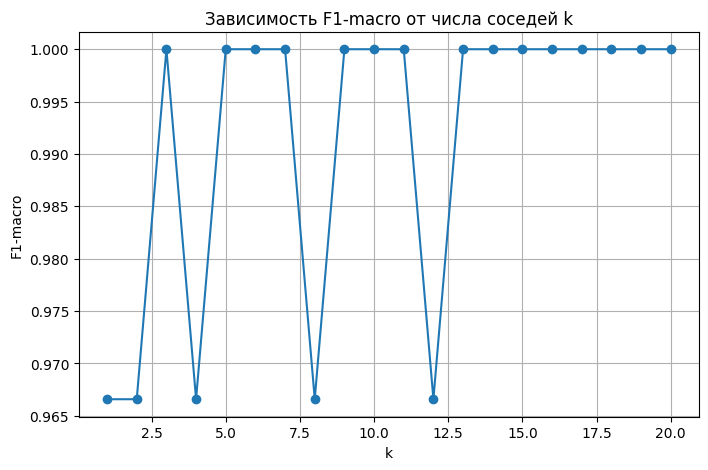

In [132]:
## подбираем оптимально K

results = []
# задается range значений
k_values = range(1,21)

for k in k_values :
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scalled,y_train)

    y_val_pred = knn.predict(X_val_scalled)

    f1 = f1_score(y_val,y_val_pred,average="macro")

    results.append({
        "k": k,
        "f1_macro" : f1
    })

df_results = pd.DataFrame(results)
print("Таблица резалтов : ")
print(df_results.sort_values(by="f1_macro",ascending=False))

# строим графики
plt.figure(figsize=(8,5))
plt.plot(df_results['k'],df_results["f1_macro"], marker="o")
plt.title("Зависимость F1-macro от числа соседей k")
plt.xlabel("k")
plt.ylabel("F1-macro")
plt.grid(True)
plt.show()

Таблица резалтов : 
      metric  f1_macro
0  euclidean       1.0
1  manhattan       1.0
2  minkowski       1.0


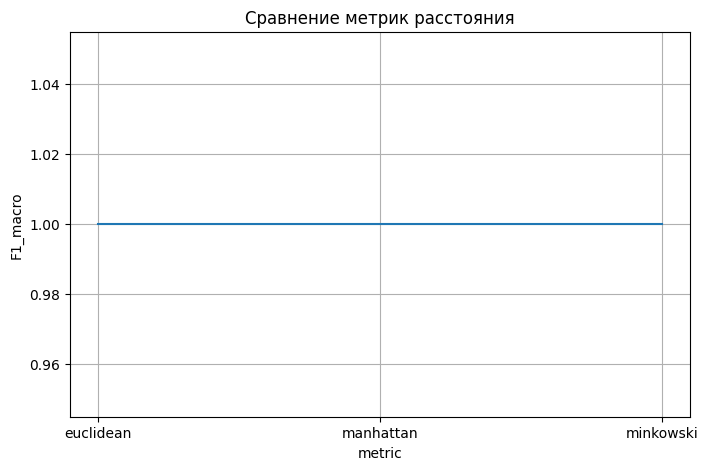

In [133]:
## сравнение метрик, при k=5
result_dist =[]

metrics_dist = ["euclidean","manhattan","minkowski"]

for metric in metrics_dist:
    knn = KNeighborsClassifier(n_neighbors=5,metric=metric,weights="uniform")
    knn.fit(X_train_scalled,y_train)
    
    y_val_pred =  knn.predict(X_val_scalled)
    
    f1 = f1_score(y_val,y_val_pred,average="macro")
        
    result_dist.append({
            "metric": metric,
            "f1_macro" : f1
    })
        
df_results_dist = pd.DataFrame(result_dist)
print("Таблица резалтов : ")
print(df_results_dist.sort_values(by="f1_macro",ascending=False))

plt.figure(figsize=(8,5))
plt.plot(df_results_dist["metric"],df_results_dist["f1_macro"])
plt.title("Сравнение метрик расстояния")
plt.xlabel("metric")
plt.ylabel("F1_macro")
plt.grid(True)
plt.show()    

Таблица резалтов :
     weight  f1_macro
0   uniform       1.0
1  distance       1.0


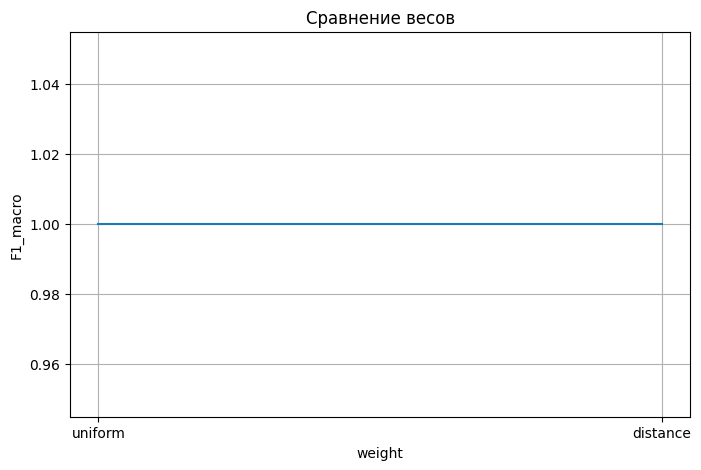

In [134]:
## сравнение весов, k=5, metric=euclidean

results_weights = []

metric_weights = ["uniform","distance"]

for weight in metric_weights:
    knn = KNeighborsClassifier(n_neighbors=5,metric="euclidean",weights=weight)
    knn.fit(X_train_scalled,y_train)
    
    y_val_pred = knn.predict(X_val_scalled)
    
    f1 = f1_score(y_val,y_val_pred,average="macro")
    
    results_weights.append({
        "weight": weight,
        "f1_macro": f1
    })
    
df_results_weights = pd.DataFrame(results_weights)
print("Таблица резалтов :")
print(df_results_weights.sort_values(by="f1_macro",ascending=False))

plt.figure(figsize=(8,5))
plt.plot(df_results_weights["weight"],df_results_weights["f1_macro"])
plt.title("Сравнение весов")
plt.xlabel("weight")
plt.ylabel("F1_macro")
plt.grid(True)
plt.show()


### Выводы по блоку
при k=5 модель показывает хорошие статы, f1_macro держится на 1.0 метрики и веса не показали различий

## 6) Оценка совокупности гиперпараметров и выбор оптимального

In [135]:
## оценка совокупности гиперпараметров
all_results=[]

for k in k_values:
    for metric in metrics_dist:
        for weight in metric_weights:
            knn = KNeighborsClassifier(n_neighbors=k,metric=metric,weights=weight)
            knn.fit(X_train_scalled,y_train)
            
            y_val_pred = knn.predict(X_val_scalled)
            
            f1 = f1_score(y_val,y_val_pred,average="macro")
            
            all_results.append({
                "k": k,
                "metric": metric,
                "weight": weight,
                "f1_macro": f1
            })
            
df_all_results = pd.DataFrame(all_results)
print("Таблица резалтов")
print(df_all_results.sort_values(by="f1_macro",ascending=False).head(20))

Таблица резалтов
    k     metric    weight  f1_macro
16  3  minkowski   uniform       1.0
17  3  minkowski  distance       1.0
12  3  euclidean   uniform       1.0
13  3  euclidean  distance       1.0
47  8  minkowski  distance       1.0
43  8  euclidean  distance       1.0
53  9  minkowski  distance       1.0
52  9  minkowski   uniform       1.0
40  7  minkowski   uniform       1.0
41  7  minkowski  distance       1.0
39  7  manhattan  distance       1.0
38  7  manhattan   uniform       1.0
36  7  euclidean   uniform       1.0
37  7  euclidean  distance       1.0
34  6  minkowski   uniform       1.0
35  6  minkowski  distance       1.0
31  6  euclidean  distance       1.0
30  6  euclidean   uniform       1.0
29  5  minkowski  distance       1.0
28  5  minkowski   uniform       1.0


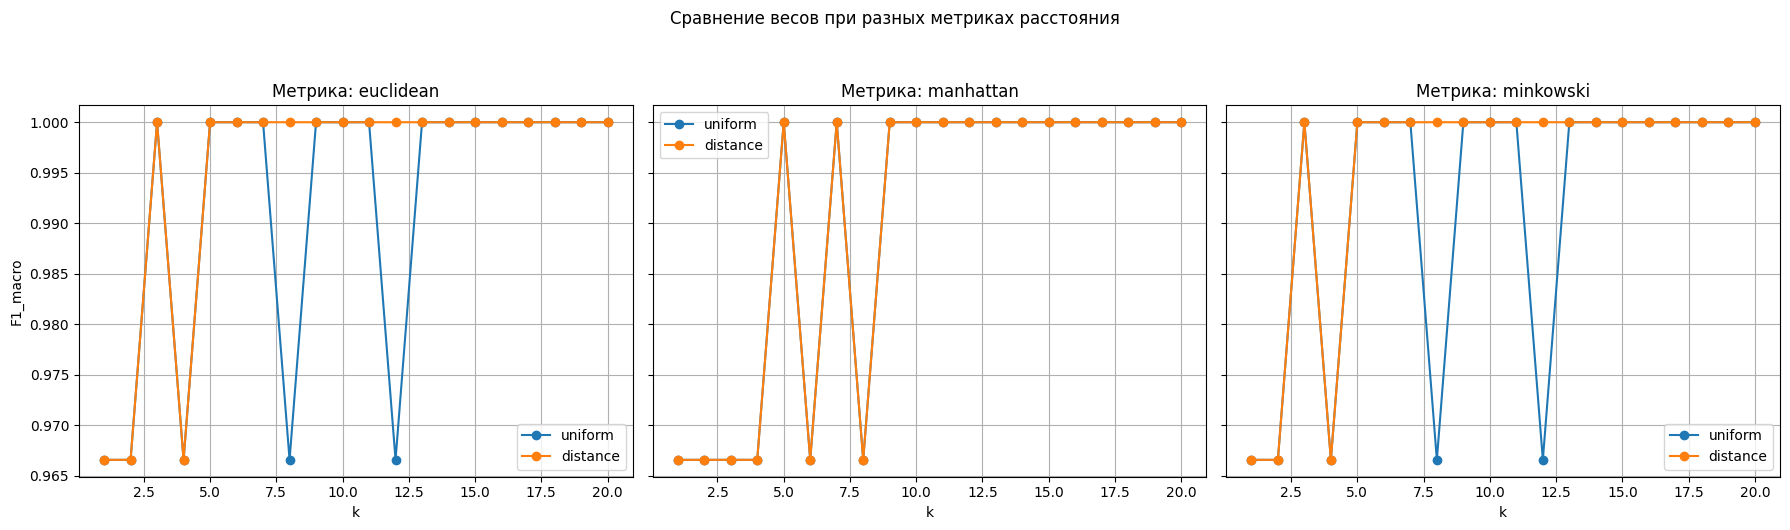

In [136]:
# строим графики для наглядности
fig,axes = plt.subplots(1,3,figsize=(18,5), sharey=True)

for i,metric in enumerate(metrics_dist):
    ax = axes[i]
    
    for weight in metric_weights:
        subset = df_all_results[(df_all_results["metric"] == metric) & (df_all_results["weight"] == weight)].sort_values(by="k")
        
        ax.plot(subset["k"],subset["f1_macro"],marker="o",label=weight)
    ax.set_title(f"Метрика: {metric}")
    ax.set_xlabel('k')
    ax.grid(True)
    ax.legend()

axes[0].set_ylabel("F1_macro")

plt.suptitle("Сравнение весов при разных метриках расстояния", y=1.05)
plt.tight_layout()
plt.show()
        

### Выводы по блоку
По графикам видно, что на манхетане веса не имею значения, по остальным наглядно все видно. Также пришел к выводу что для финального теста буду юзать euclidean + distance + k=8 по метрике f1_macro дает 1.0 и евклидиан более понятен) смотрел по таблице выше 

## 7) Финальное обучение KNN и юз на тестовых данных

In [ ]:
## финальный knn
best_knn = KNeighborsClassifier(n_neighbors=8,metric="euclidean",weights="distance")

best_knn.fit(X_train_scalled,y_train)

y_test_predicted = best_knn.predict(X_test_scalled)

cm_res = confusion_matrix(y_test,y_test_predicted)
cm_res_df = pd.DataFrame(cm_res,index=best_knn.classes_,columns=best_knn.classes_)

print(f"Accuracy score --> {accuracy_score(y_test,y_test_predicted)}")
print("\nClassification report : ")
print(classification_report(y_test,y_test_predicted))
print("\n confussion matrix : ")
print(cm_res_df)

Accuracy score --> 1.0

Classification report : 
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


 confussion matrix : 
                 Iris-setosa  Iris-versicolor  Iris-virginica
Iris-setosa               10                0               0
Iris-versicolor            0               10               0
Iris-virginica             0                0              10


## 8) Выводы по работе
выше в прицнипе все описал, только большую часть делал ручками поэтому не юзал Pypilene,GridSearchCV и тд; 
на тесте все гуд, по матрице ошибок нет 